# Pre-deforestation


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load all dependencies, including your own model through ewatercycle_wrapper_HBV
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
from ipywidgets import IntProgress
from IPython.display import display
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ewatercycle_wrapper_HBV import HBV



In [3]:
experiment_start_time  = "2014-01-01T00:00:00Z"
experiment_end_time    = "2024-12-31T00:00:00Z"

# calibration_start_time = "2014-01-01T00:00:00Z"
# calibration_end_time   = "2022-12-31T00:00:00Z"

validation_start_time  = "2023-01-01T00:00:00Z"
validation_end_time    = "2024-12-31T00:00:00Z"

#recommended
# Pre-deforestation calibration window
calibration_start_time = "2014-01-01T00:00:00Z"
calibration_end_time   = "2019-12-31T00:00:00Z"


Set Up

In [6]:
#discharge
df = pd.read_csv(
    './Data/5202080_Q_Day.Cmd.txt',
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252'
)
df.columns = ["Date", "Time", "Discharge"]
df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
df = df.dropna(subset=["Discharge"])
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df = df.set_index("Date")
df = df.drop(columns=["Time"])
df = df.sort_index()

#precip
precip = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip["Date"] = pd.to_datetime(precip["system:index"], format="%Y%m%d")
precip = precip.set_index("Date")[["total_precipitation_sum"]]
precip = precip.rename(columns={"total_precipitation_sum": "pr"})
precip["pr"] = precip["pr"] * 1000   # m/day → mm/day

#evap
# evap = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
# evap["Date"] = pd.to_datetime(evap["system:index"], format="%Y%m%d")
# evap = evap.set_index("Date")[["potential_evaporation_sum"]]
# evap = evap.rename(columns={"potential_evaporation_sum": "evspsblpot"})
# evap["evspsblpot"] = evap["evspsblpot"].abs() * 1000   # m/day → mm/day
evap = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap["Date"] = pd.to_datetime(evap["system:index"], format="%Y%m%d")

# FIX: use the correct column name from the file
evap = evap.set_index("Date")[["total_evaporation_sum"]]

evap = evap.rename(columns={"total_evaporation_sum": "evspsblpot"})
evap["evspsblpot"] = evap["evspsblpot"].abs() * 1000   # m/day → mm/day


common_dates = (
    df.index
    .intersection(precip.index)
    .intersection(evap.index)
)

df_q = df.loc[common_dates].copy()
pr   = precip.loc[common_dates].copy()
evap = evap.loc[common_dates].copy()
#units
shape_area_manning = 6642 * 1e6   # m²

Obs = df_q.copy()
Obs.columns = ["Q"]
Obs["Q"] = Obs["Q"] * 86400 / shape_area_manning * 1000   # m³/s → mm/day
Obs.loc[Obs["Q"] > 4000, "Q"] = np.nan
Obs = Obs.sort_index()
#forcing
forcing_df = pr.join(evap, how="inner").sort_index()
forcing_df.index = forcing_df.index.normalize()
forcing_df.index = pd.to_datetime(forcing_df.index).normalize()

print("Final forcing_df head:")
print(forcing_df.head())

print("Final Obs head:")
print(Obs.head())


Final forcing_df head:

pr  evspsblpot
Date                            
1981-01-01  0.002726    4.167119
1981-01-02  0.011808    4.042314
1981-01-03  0.010592    3.829935
1981-01-04  1.722625    3.421463
1981-01-05  1.125538    3.357310

Final Obs head:

Q
Date                
1981-01-01  0.062998
1981-01-02  0.071805
1981-01-03  0.062465
1981-01-04  0.066654
1981-01-05  0.050693

In [7]:
import os
print(os.access("Forcing", os.W_OK))


True

In [8]:

ds = xr.Dataset(
    data_vars={
        "pr": ("time", forcing_df["pr"].values),
        "evspsblpot": ("time", forcing_df["evspsblpot"].values),
    },
    coords={
        "time": forcing_df.index.values
    },
    attrs={"title": "Manning HBV forcing using custom precipitation and evaporation"}
)

ds["pr"].attrs["units"] = "mm/day"
ds["evspsblpot"].attrs["units"] = "mm/day"

ds.to_netcdf("Forcing/manning_hbv_forcing_custom.nc")


In [9]:
forcing = {
    "directory": "Forcing",
    "start_time": forcing_df.index.min().strftime("%Y-%m-%dT00:00:00Z"),
    "end_time": forcing_df.index.max().strftime("%Y-%m-%dT00:00:00Z"),
    "pr": "manning_hbv_forcing_custom.nc",
    "evspsblpot": "manning_hbv_forcing_custom.nc",
}

model = HBV(forcing=forcing)


In [10]:
print("Start:", forcing_df.index.min(), type(forcing_df.index.min()))
print("End:", forcing_df.index.max(), type(forcing_df.index.max()))

print("Formatted start:", forcing_df.index.min().strftime("%Y-%m-%dT00:00:00Z"))
print("Formatted end:", forcing_df.index.max().strftime("%Y-%m-%dT00:00:00Z"))


Start: 1981-01-01 00:00:00 <class 'pandas._libs.tslibs.timestamps.Timestamp'>

End: 2025-04-27 00:00:00 <class 'pandas._libs.tslibs.timestamps.Timestamp'>

Formatted start: 1981-01-01T00:00:00Z

Formatted end: 2025-04-27T00:00:00Z

Calibration

In [11]:
# #                   Imax Ce Sumax beta Pmax   Tlag   Kf  Ks
# ParMinn = np.array([0,   0.2,  40,    .5,   .001,   0,     .01,  .0001])
# ParMaxn = np.array([8,    1,  800,   4,    .3,     10,    .1,   .01])
# Sin = np.array([0,  100,  0,  5  ])
# s_0 = np.array([2,  390,  80,  39  ])

# # The names of the parameters are constant for all models
# p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
# param_names = ["Imax","Ce",  "Sumax", "beta",  "Pmax",  "Tlag",   "Kf",   "Ks"]
# The number of ensemble members in our ensemble
# N = 1000

# p_min_initial = np.array([0,   0.4,  40,    1,   .001,   1,     .01,  .0001])
# p_max_initial = np.array([8,    0.8,  800,   2.5,    .3,     3,    .1,   .01])


# parameters = np.zeros([8, N])

# np.random.seed(6)
# for param in range(8):
#     parameters[param,:] = np.random.uniform(p_min_initial[param],p_max_initial[param],N)
    
# ensemble = []

# for counter in range(N): 
#     ensemble.append(HBV(forcing=ERA5_forcing))
#     config_file, _ = ensemble[counter].setup(
#                             parameters = ','.join([str(p) for p in parameters[:,counter]]),
#                             initial_storage=','.join([str(s) for s in s_0]),
#                             cfg_dir = "configFiles/hbv_ensembleMember_" + str(counter),
#                                )
#     ensemble[counter].initialize(config_file)

# # Objectivr function
# def calibrationObjective(modelOutput, observation, start_calibration, end_calibration):
#     # Combine the two in one dataFrame
#     hydro_data = pd.concat([modelOutput.reindex(observation.index, method = 'ffill'), observation], axis=1)

#     # Only select the calibration period
#     hydro_data = hydro_data[hydro_data.index > pd.to_datetime(pd.Timestamp(start_calibration).date())]
#     hydro_data = hydro_data[hydro_data.index < pd.to_datetime(pd.Timestamp(end_calibration).date())]

#     modelOutput = hydro_data['model output']
#     observation = hydro_data['Q']

#     nan_index = np.where(np.isnan(observation))[0]
#     observation.iloc[nan_index] = (observation.iloc[nan_index - 1].values + observation.iloc[nan_index + 1].values) / 2 # set the nan value to an average of the value before and after
    
#     nse = 1 - (np.sum((modelOutput - observation)**2) / np.sum((observation - observation.mean())**2))
#     log_nse = 1 - (np.sum((np.log(modelOutput) - np.log(observation))**2) / np.sum((np.log(observation) - np.log(observation).mean())**2))
#     De = np.sqrt((1-nse)**2 + (1-log_nse)**2)
#     return nse, log_nse, De

# # An object to show a progress bar, since this can take a while:
# f = IntProgress(min=0, max=N) # instantiate the bar
# display(f) # display the bar

# # An empty array to store the results in
# objectives = []

# # Loop over all ensemble members
# for ensembleMember in ensemble:
#     Q_m = []
#     time = []
#     while ensembleMember.time < ensembleMember.end_time:
#         ensembleMember.update()
#         discharge_this_timestep = ensembleMember.get_value("Q") * shape_area / (1000 * 86400)
#         Q_m.append(discharge_this_timestep[0])
#         time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))
    
#     # Calculate the objective function 
#     discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))
#     objective_this_model = calibrationObjective(discharge_dataframe,obs,calibration_start_time,calibration_end_time)
#     objectives.append(objective_this_model)

#     # It is good practice to remove any variable you don't need anymore to save memory.
#     del Q_m, time, discharge_dataframe, objective_this_model

#     # Update progress bar
#     f.value += 1

# # Finally, we remove the models themselves to save up space and memory.
# for ensembleMember in ensemble:
#     ensembleMember.finalize()

# # Plotting the calibration parameters
# xFigNr = 2
# yFigNr = 4

# fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr,figsize = (15,15))
# fig_nselog, axs_nselog = plt.subplots(xFigNr, yFigNr,figsize = (15,15))

# nse_values = [i[0] for i in objectives]
# log_nse_values = [i[1] for i in objectives]


# for xFig in range(xFigNr):
#     for yFig in range(yFigNr):
#         paramCounter = xFig*yFigNr + yFig
#         # Extract NSE and log NSE for all runs
#         axs_nse[xFig,yFig].plot(parameters[paramCounter,:],nse_values,'.', label='NSE')
#         axs_nse[xFig,yFig].set_title(p_names[paramCounter])
        
#         axs_nselog[xFig,yFig].plot(parameters[paramCounter,:],log_nse_values,'.', label='log NSE')
#         axs_nselog[xFig,yFig].set_title(p_names[paramCounter])

#         axs_nse[xFig,yFig].legend()
#         axs_nselog[xFig,yFig].legend()
        
# # Best parameters according to NSE_values
# parameters_maximum_index = np.argmax(np.array(nse_values))
# print(f'NSE value: {nse_values[parameters_maximum_index]}')
# print(f'Parameter index: {parameters_maximum_index}')
# parameters_maximum = parameters[:,parameters_maximum_index]
# print(f'Best fitting parameters according to NSE: {parameters_maximum}')

# # Best parameters according to NSE_values
# parameters_maximum_index = np.argmax(np.array(log_nse_values))
# print(f'logNSE value: {log_nse_values[parameters_maximum_index]}')
# print(f'Parameter index: {parameters_maximum_index}')
# parameters_maximum = parameters[:,parameters_maximum_index]
# print(f'Best fitting parameters according to logNSE: {parameters_maximum}')

# # To find the best combination between the logNSE and NSE values, the De (minimum radius) is calculated, see objective function. 
# # These are the parameters that are actually use for comparison and evaluation
# De = [i[2] for i in objectives]
# parameters_index_min = np.argmin(np.array(De))
# print(f'Parameter index with lowest De: {parameters_index_min}')
# print(f'De value: {De[parameters_index_min]}')
# parameters_maximum = parameters[:,parameters_index_min]
# print(f'Best fitting parameters according to De: {parameters_maximum}')

Comparison head:

Qmodel      Qobs
1981-01-02  0.000018  0.071805
1981-01-03  0.000074  0.062465
1981-01-04  0.000166  0.066654
1981-01-05  0.000258  0.050693
1981-01-06  0.000313  0.043278

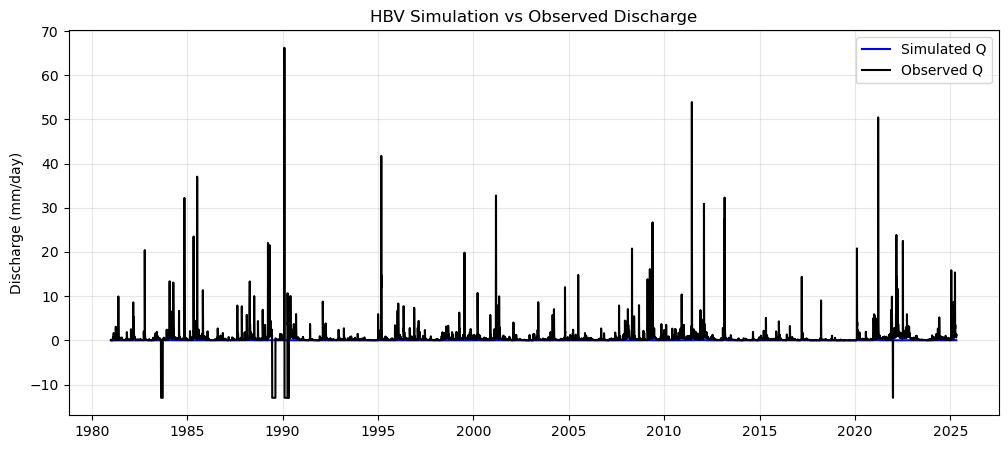

NSE = -0.026346998168299107

In [12]:



s_0 = np.array([0, 100, 0, 5])

p_min_initial = np.array([0, 0.2, 40, 0.5, 0.001, 1, 0.01, 0.0001])
p_max_initial = np.array([8, 1, 800, 4, 0.3, 10, 0.1, 0.01])
par_0 = (p_min_initial + p_max_initial) / 2   # midpoint initial guess



config_file, _ = model.setup(
    parameters=",".join([str(p) for p in par_0]),
    initial_storage=",".join([str(s) for s in s_0]),
)

model.initialize(config_file)

Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime.date()))

model.finalize()

sim = pd.DataFrame({"Qmodel_m3s": Q_m}, index=time)

# mm/day

area_m2 = 6642 * 1e6

sim["Qmodel"] = (sim["Qmodel_m3s"] * 86400 / area_m2) * 1000
sim = sim[["Qmodel"]]


comparison = sim.join(Obs, how="inner").dropna()
comparison = comparison.rename(columns={"Q": "Qobs"})

print("Comparison head:")
print(comparison.head())
#plot
plt.figure(figsize=(12,5))
plt.plot(comparison.index, comparison["Qmodel"], label="Simulated Q", color="blue")
plt.plot(comparison.index, comparison["Qobs"], label="Observed Q", color="black")
plt.legend()
plt.ylabel("Discharge (mm/day)")
plt.title("HBV Simulation vs Observed Discharge")
plt.grid(alpha=0.3)
plt.show()

#nse
def nse(qobs, qsim):
    qobs = np.asarray(qobs)
    qsim = np.asarray(qsim)
    return 1 - np.sum((qobs - qsim)**2) / np.sum((qobs - np.mean(qobs))**2)

score = nse(comparison["Qobs"], comparison["Qmodel"])
print("NSE =", score)


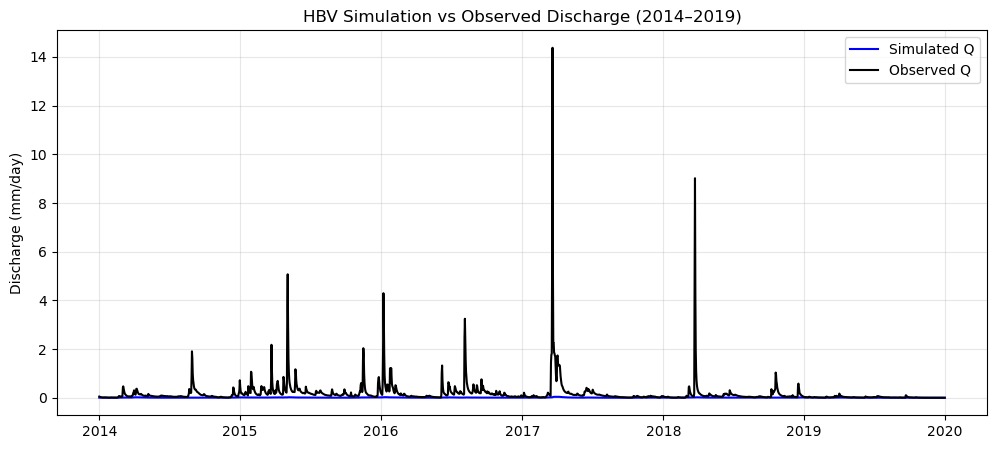

In [13]:

#  plot for 2014–2019 ---
start_2 = "2014-01-01"
end_2   = "2019-12-31"

comparison_2014_2019 = comparison.loc[start_2:end_2]

plt.figure(figsize=(12,5))
plt.plot(comparison_2014_2019.index, comparison_2014_2019["Qmodel"], 
         label="Simulated Q", color="blue")
plt.plot(comparison_2014_2019.index, comparison_2014_2019["Qobs"], 
         label="Observed Q", color="black")

plt.legend()
plt.ylabel("Discharge (mm/day)")
plt.title("HBV Simulation vs Observed Discharge (2014–2019)")
plt.grid(alpha=0.3)
plt.show()



In [14]:
# Parameter ranges (Minn/Maxn from your notebook)
ParMinn = np.array([0,   0.2,  40,   0.5,  0.001,  0,   0.01, 0.0001])
ParMaxn = np.array([8,   1.0,  800,  4.0,  0.3,    10,  0.1,  0.01])

# Initial storage
Sin = np.array([0, 100, 0, 5])
s_0 = np.array([2, 390, 80, 39])

# Ensemble size
N = 1000

# Narrowed initial sampling ranges (your p_min_initial / p_max_initial)
p_min_initial = np.array([0,   0.4,  40,   1.0, 0.001, 1.0, 0.01, 0.0001])
p_max_initial = np.array([8,   0.8,  800,  2.5, 0.3,   3.0, 0.1,  0.01])

parameters = np.zeros((8, N))

np.random.seed(6)
for param in range(8):
    parameters[param, :] = np.random.uniform(
        p_min_initial[param],
        p_max_initial[param],
        N,
    )


In [15]:
prec = pd.read_csv("Data/manning_ERA5_precip_daily.csv")
evap = pd.read_csv("Data/manning_ERA5_evap_daily.csv")

print(prec.head())
print(prec.columns)
print(evap.head())
print(evap.columns)

system:index  total_precipitation_sum
0      19810101                 0.000003
1      19810102                 0.000012
2      19810103                 0.000011
3      19810104                 0.001723
4      19810105                 0.001126

Index(['system:index', 'total_precipitation_sum'], dtype='object')

system:index  total_evaporation_sum
0      19810101              -0.004167
1      19810102              -0.004042
2      19810103              -0.003830
3      19810104              -0.003421
4      19810105              -0.003357

Index(['system:index', 'total_evaporation_sum'], dtype='object')

In [16]:
prec["date"] = pd.to_datetime(prec["system:index"], format="%Y%m%d")
evap["date"] = pd.to_datetime(evap["system:index"], format="%Y%m%d")
print(prec[["system:index", "date"]].head())
print(evap[["system:index", "date"]].head())
prec = prec.set_index("date")
evap = evap.set_index("date")
prec = prec.rename(columns={"total_precipitation_sum": "pr"})
evap = evap.rename(columns={"total_evaporation_sum": "evspsblpot"})
prec["pr"] = prec["pr"] * 1000
evap["evspsblpot"] = evap["evspsblpot"].abs() * 1000


system:index       date
0      19810101 1981-01-01
1      19810102 1981-01-02
2      19810103 1981-01-03
3      19810104 1981-01-04
4      19810105 1981-01-05

system:index       date
0      19810101 1981-01-01
1      19810102 1981-01-02
2      19810103 1981-01-03
3      19810104 1981-01-04
4      19810105 1981-01-05

In [17]:
# Name of your shapefile/region without extension:
own_region = "manning" #for example: "Rhine"

# Shapefile that describes the basin we want to study.
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# # Location to saved forcing results from previous notebook
# forcingLocation = forcing_path / f"{own_region}_Forcing"

# ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)
# print(ERA5_forcing)

In [18]:
N = 500
ensemble = []

for counter in range(N):

    # Create model with your custom forcing dictionary
    model = HBV(forcing=forcing)

    # Build config file for this ensemble member
    config_file, _ = model.setup(
        parameters=",".join([str(p) for p in parameters[:, counter]]),
        initial_storage=",".join([str(s) for s in s_0]),
        cfg_dir=f"configFiles/hbv_ensembleMember_{counter}",
    )

    # Initialize model
    model.initialize(config_file)

    # Store in ensemble list
    ensemble.append(model)


In [19]:
def calibrationObjective(modelOutput, observation, start_calibration, end_calibration):

    # Align model and obs on the same index
    hydro_data = pd.concat(
        [modelOutput.reindex(observation.index, method="ffill"), observation],
        axis=1,
    )

    # Inclusive date range
    start = pd.to_datetime(start_calibration[:10])
    end   = pd.to_datetime(end_calibration[:10])

    hydro_data = hydro_data[(hydro_data.index >= start) & (hydro_data.index <= end)]

    # Extract columns safely
    modelOutput = hydro_data.iloc[:, 0]
    observation = hydro_data.iloc[:, 1]

    # SAFE NaN handling
    observation = observation.interpolate(limit_direction="both")

    # NSE
    nse = 1 - (
        np.sum((modelOutput - observation) ** 2)
        / np.sum((observation - observation.mean()) ** 2)
    )

    # log NSE (with epsilon)
    eps = 1e-6
    log_nse = 1 - (
        np.sum((np.log(modelOutput + eps) - np.log(observation + eps)) ** 2)
        / np.sum((np.log(observation + eps) - np.log(observation + eps).mean()) ** 2)
    )

    # Combined metric
    De = np.sqrt((1 - nse) ** 2 + (1 - log_nse) ** 2)

    return nse, log_nse, De


In [ ]:

# pre-deforestation calibration 
predef_start = "2014-01-01T00:00:00Z"
predef_end   = "2019-12-31T00:00:00Z"

# progress bar  2014–2019 
f = IntProgress(min=0, max=N)
display(f)

objectives = []

for ensembleMember in ensemble:
    Q_m = []
    time = []

    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()

        # Convert m3/s → mm/day
        discharge_this_timestep = (
            ensembleMember.get_value("Q")[0] * 86400 / shape_area_manning * 1000
        )

        Q_m.append(discharge_this_timestep)
        time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))

    # Build model output dataframe
    discharge_dataframe = pd.DataFrame(
        {"model output": Q_m},
        index=pd.to_datetime(time),
    )

    # Compute objective function ONLY over 2014–2019
    objective_this_model = calibrationObjective(
        discharge_dataframe,
        Obs,
        predef_start,
        predef_end,
    )
    objectives.append(objective_this_model)


    del Q_m, time, discharge_dataframe, objective_this_model

    f.value += 1

# Finalize models
for ensembleMember in ensemble:
    ensembleMember.finalize()


IntProgress(value=0, max=500)

In [21]:
# # Progress bar
# f = IntProgress(min=0, max=N)
# display(f)
# objectives = []
# for ensembleMember in ensemble:
#     Q_m = []
#     time = []

#     while ensembleMember.time < ensembleMember.end_time:
#         ensembleMember.update()

#         # Convert m3/s → mm/day
#         discharge_this_timestep = (
#             ensembleMember.get_value("Q")[0] * 86400 / shape_area_manning * 1000
#         )

#         Q_m.append(discharge_this_timestep)
#         time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))

#     # Build model output dataframe
#     discharge_dataframe = pd.DataFrame(
#         {"model output": Q_m},
#         index=pd.to_datetime(time),
#     )
#     # Compute objective function
#     objective_this_model = calibrationObjective(
#     discharge_dataframe,
#     Obs,
#     predef_start,
#     predef_end,
#     )
#     objectives.append(objective_this_model)
#     # Clean up
#     del Q_m, time, discharge_dataframe, objective_this_model

#     f.value += 1
# # Finalize models
# for ensembleMember in ensemble:
#     ensembleMember.finalize()


IntProgress(value=0, max=500)

KeyboardInterrupt: 

In [13]:
# # recommended to look at just pre
# predef_start = "2014-01-01T00:00:00Z"
# predef_end   = "2019-12-31T00:00:00Z"

# # Progress bar
# f = IntProgress(min=0, max=N)
# display(f)

# objectives = []

# for ensembleMember in ensemble:
#     Q_m = []
#     time = []

#     while ensembleMember.time < ensembleMember.end_time:
#         ensembleMember.update()

#         # Convert m3/s → mm/day
#         discharge_this_timestep = (
#             ensembleMember.get_value("Q")[0] * 86400 / shape_area_manning * 1000
#         )

#         Q_m.append(discharge_this_timestep)
#         time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))

#     # Build model output dataframe
#     discharge_dataframe = pd.DataFrame(
#         {"model output": Q_m},
#         index=pd.to_datetime(time),
#     )

#     # Compute objective function
#     objective_this_model = calibrationObjective(
#     discharge_dataframe,
#     Obs,
#     predef_start,
#     predef_end,
#     )

#     objectives.append(objective_this_model)

#     # Clean up
#     del Q_m, time, discharge_dataframe, objective_this_model

#     f.value += 1

# # Finalize models
# for ensembleMember in ensemble:
#     ensembleMember.finalize()

# Model Calibration

### Calibration 
For the model calibration the NSE, logNSE and the minimal De were used to find the optimal parameters.

In [ ]:
# Parameter names
p_names = ["Imax", "Ce", "Sumax", "beta", "Pmax", "Tlag", "Kf", "Ks"]

# NSE and logNSE 
nse_values = np.array([obj[0] for obj in objectives])
log_nse_values = np.array([obj[1] for obj in objectives])

#  parameter vs NSE / logNSE 
xFigNr = 2
yFigNr = 4

fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))
fig_nselog, axs_nselog = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))

for xFig in range(xFigNr):
    for yFig in range(yFigNr):
        paramCounter = xFig * yFigNr + yFig

        axs_nse[xFig, yFig].plot(parameters[paramCounter, :], nse_values, '.', alpha=0.5)
        axs_nse[xFig, yFig].set_title(p_names[paramCounter])
        axs_nse[xFig, yFig].set_xlabel(p_names[paramCounter])
        axs_nse[xFig, yFig].set_ylabel("NSE")

        axs_nselog[xFig, yFig].plot(parameters[paramCounter, :], log_nse_values, '.', alpha=0.5)
        axs_nselog[xFig, yFig].set_title(p_names[paramCounter])
        axs_nselog[xFig, yFig].set_xlabel(p_names[paramCounter])
        axs_nselog[xFig, yFig].set_ylabel("log NSE")

plt.tight_layout()
plt.show()

# Best ensemble member - NSE 
parameters_maximum_index = np.argmax(nse_values)

print(f"Best NSE value: {nse_values[parameters_maximum_index]}")
print(f"Ensemble member index: {parameters_maximum_index}")

parameters_maximum = parameters[:, parameters_maximum_index]

print("Best fitting parameters according to NSE:")
for name, value in zip(p_names, parameters_maximum):
    print(f"  {name}: {value}")

# --- Best ensemble member according to logNSE ---
lognse_max_index = np.argmax(log_nse_values)

print(f"\nBest logNSE value: {log_nse_values[lognse_max_index]}")
print(f"Ensemble member index: {lognse_max_index}")

parameters_maximum_lognse = parameters[:, lognse_max_index]

print("Best fitting parameters according to logNSE:")
for name, value in zip(p_names, parameters_maximum_lognse):
    print(f"  {name}: {value}")


NameError: name 'parameters' is not defined

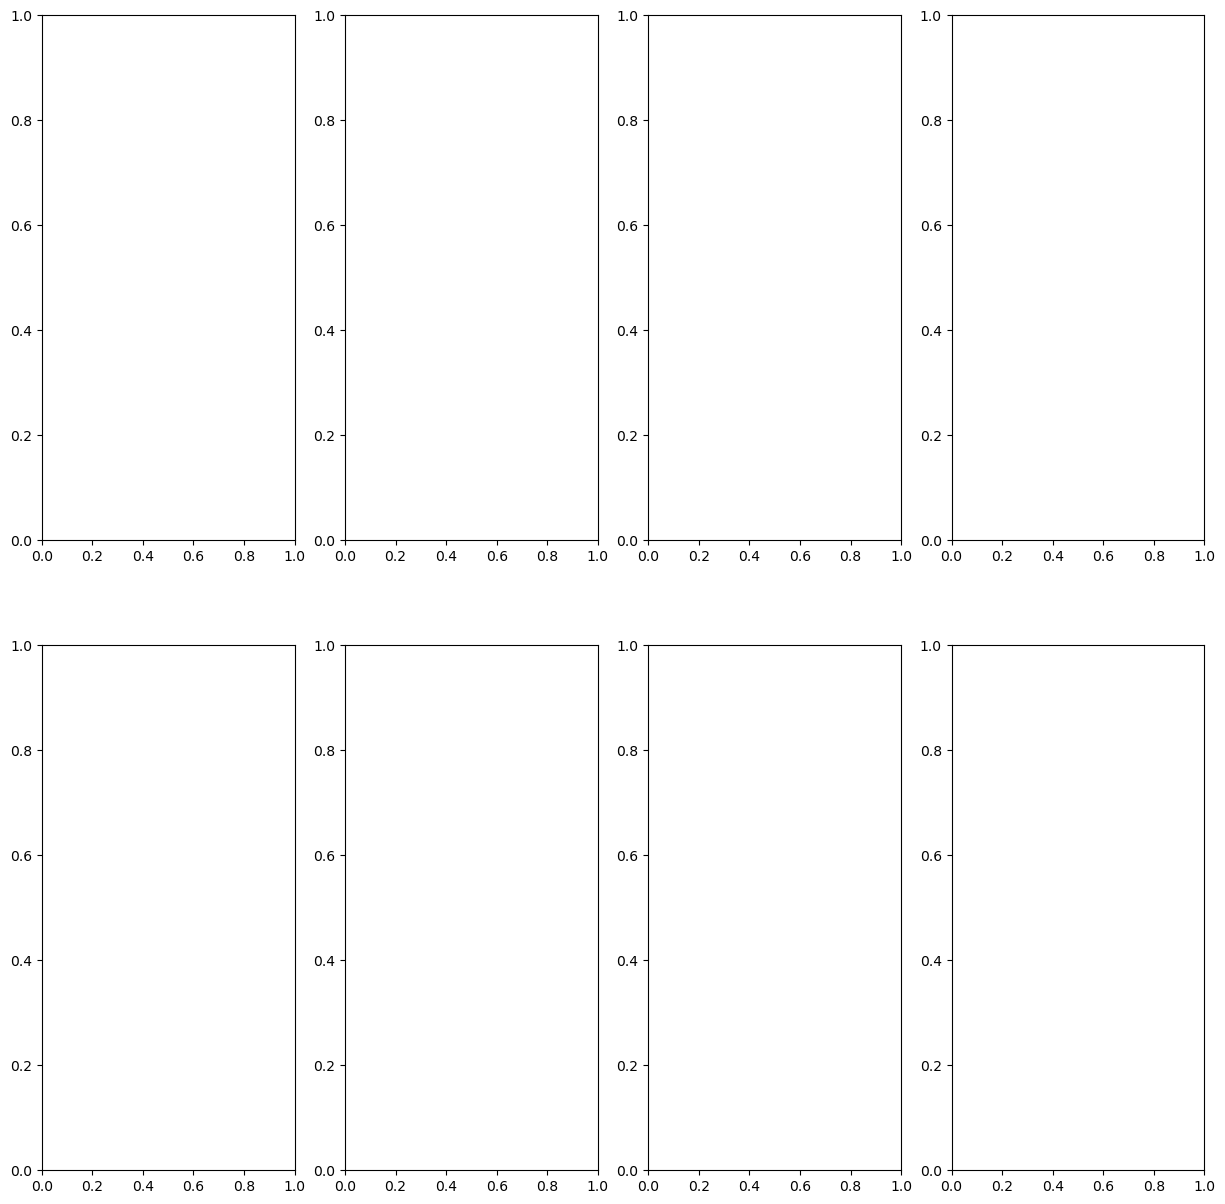

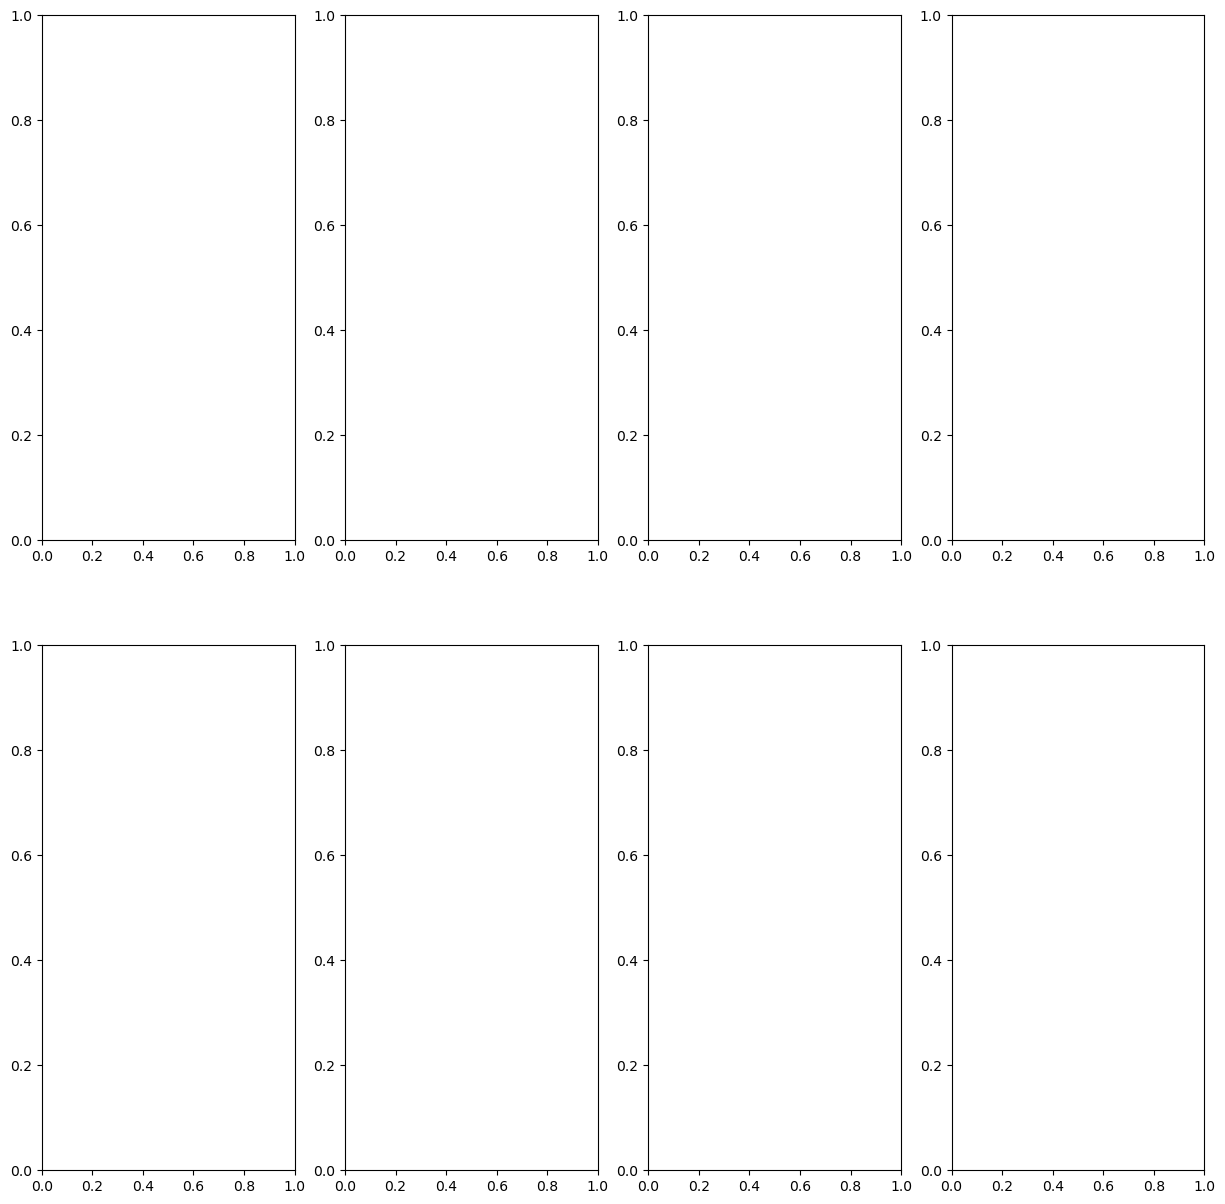

In [13]:
# #NSE = The Nash–Sutcliffe model efficiency coefficient 
# p_names = ["Imax", "Ce", "Sumax", "beta", "Pmax", "Tlag", "Kf", "Ks"]


# nse_values = np.array([obj[0] for obj in objectives])
# log_nse_values = np.array([obj[1] for obj in objectives])


# # Number of rows/columns for subplots
# xFigNr = 2
# yFigNr = 4

# fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))
# fig_nselog, axs_nselog = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))

# for xFig in range(xFigNr):
#     for yFig in range(yFigNr):
#         paramCounter = xFig * yFigNr + yFig
        
#         axs_nse[xFig, yFig].plot(parameters[paramCounter, :], nse_values, '.', alpha=0.5)
#         axs_nse[xFig, yFig].set_title(p_names[paramCounter])
#         axs_nse[xFig, yFig].set_xlabel(p_names[paramCounter])
#         axs_nse[xFig, yFig].set_ylabel("NSE")

#         axs_nselog[xFig, yFig].plot(parameters[paramCounter, :], log_nse_values, '.', alpha=0.5)
#         axs_nselog[xFig, yFig].set_title(p_names[paramCounter])
#         axs_nselog[xFig, yFig].set_xlabel(p_names[paramCounter])
#         axs_nselog[xFig, yFig].set_ylabel("log NSE")

# plt.tight_layout()
# plt.show()


In [ ]:
# # Convert NSE list to array
# nse_values = np.array([obj[0] for obj in objectives])

# # Index of the best-performing ensemble member
# parameters_maximum_index = np.argmax(nse_values)

# print(f"Best NSE value: {nse_values[parameters_maximum_index]}")
# print(f"Ensemble member index: {parameters_maximum_index}")

# # Extract the corresponding parameter set
# parameters_maximum = parameters[:, parameters_maximum_index]

# print("Best fitting parameters according to NSE:")
# for name, value in zip(p_names, parameters_maximum):
#     print(f"  {name}: {value}")


In [ ]:
print(ensemble[0].start_time_as_datetime)
print(ensemble[0].end_time_as_datetime)

obs.loc["2011"].head()
obs.loc["2011"].tail()

forcing.loc["2011"].head()
forcing.loc["2011"].tail()


In [ ]:
print(evap.time.min().values)
print(prec.time.min().values)


In [ ]:
# Best parameters according to NSE_values
parameters_maximum_index = np.argmax(np.array(log_nse_values))
print(f'logNSE value: {log_nse_values[parameters_maximum_index]}')
print(f'Parameter index: {parameters_maximum_index}')
parameters_maximum = parameters[:,parameters_maximum_index]
print(f'Best fitting parameters according to logNSE: {parameters_maximum}')

In [ ]:
# To find the best combination between the logNSE and NSE values, the De (minimum radius) is calculated, see objective function. 
# These are the parameters that are actually use for comparison and evaluation
De = [i[2] for i in objectives]
parameters_index_min = np.argmin(np.array(De))
print(f'Parameter index with lowest De: {parameters_index_min}')
print(f'De value: {De[parameters_index_min]}')
parameters_maximum = parameters[:,parameters_index_min]
print(f'Best fitting parameters according to De: {parameters_maximum}')

# Modeled Discharge vs. Observed Discharge Pre-deforestation

Using the calibrated parameters (with the minimal De), the model is run for the period it was calibrated on (1991-1994).

In [ ]:
# Load ERA5 data 1996
own_region = "mannings"

path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}manningForcing"

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

In [ ]:
# Q modeled
par = np.array(parameters_maximum) # From De optimisation
s_0 = np.array([0,  100,  0,  5])

model = HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(
                            parameters=','.join([str(p) for p in par]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    discharge_this_timestep = model.get_value("Q")
    Q_m.append(discharge_this_timestep[0])
    time.append(pd.Timestamp(model.time_as_datetime.date())) 
    
df = pd.DataFrame(data=Q_m,columns=["Modeled discharge"], index=time)

shape_area = 1083.18 * 1000000 # m2
df["Modeled discharge"] = df["Modeled discharge"] * shape_area / (1000 * 86400)
sim_data = df["Modeled discharge"].to_xarray().rename({'index': 'date'}) 
sim_data.name = 'Simulated data'

In [ ]:
# Q observed 
obs = pd.read_excel('5202080_Q_Day.Cmd.txt', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2014-01-01':'2022-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [ ]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()

(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Hydrograph 1991-1994'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

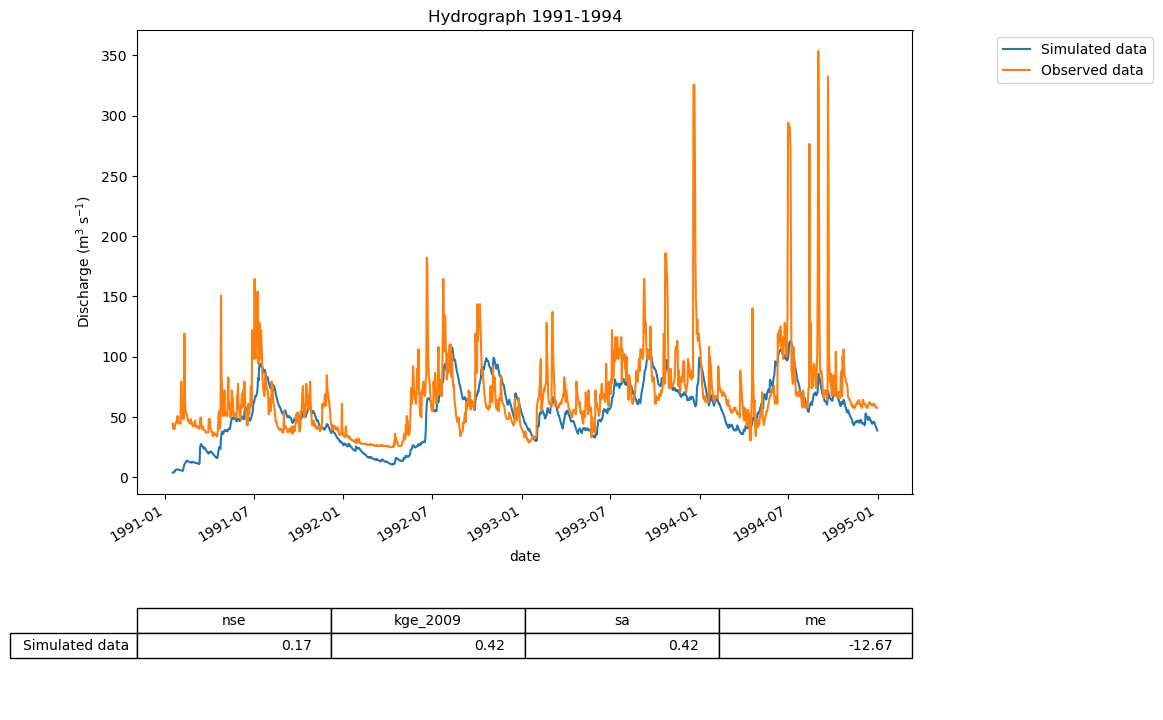

In [ ]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = 'Hydrograph_Model_19911994.png', title = 'Hydrograph 1991-1994')

In [ ]:
model.finalize()

### Validation
In the following part is looked how well the calibrated parameters perform in other time periods.

### 1996-1999

In [ ]:
# Q observed 
obs = pd.read_excel('5202080_Q_Day.Cmd.txt', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2023-01-01':'2024-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [ ]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
1996-01-01,115.137143,116.0
1996-01-02,114.757577,113.0
1996-01-03,113.404648,110.0
1996-01-04,110.642989,113.0
1996-01-05,113.190660,110.0
...,...,...
1999-12-27,101.838635,128.0
1999-12-28,101.350811,206.5
1999-12-29,101.891028,113.0


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 1996-1999'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

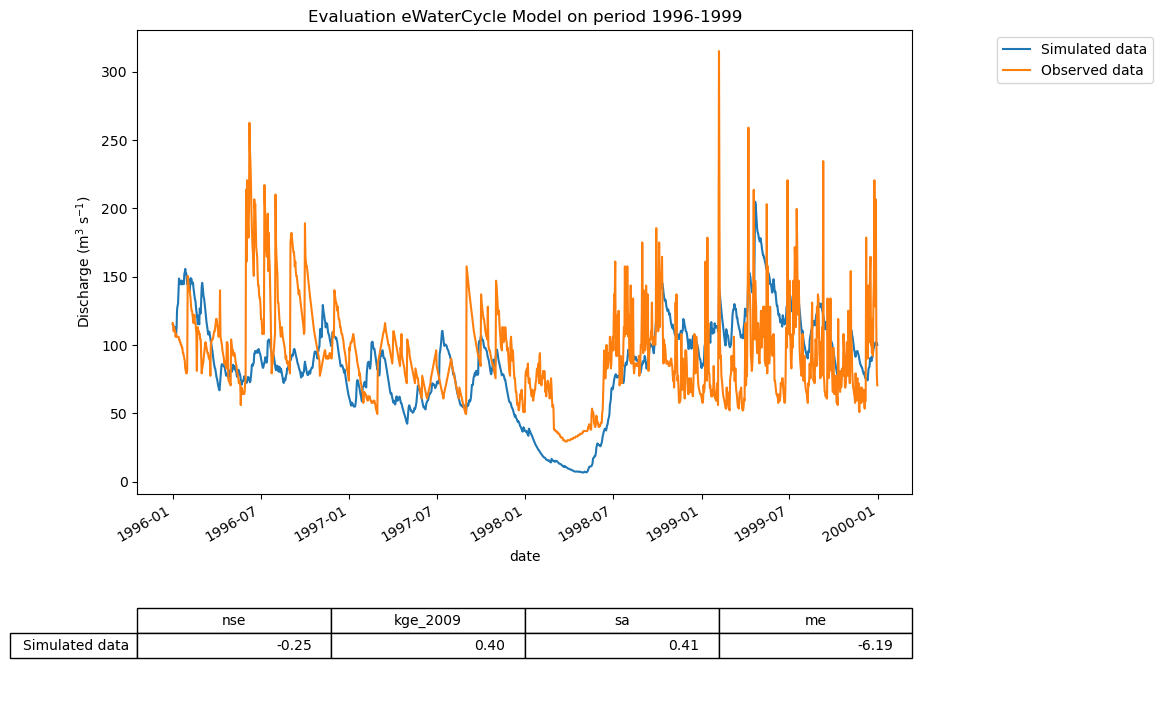

In [ ]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_19961999.png', title = 'Evaluation eWaterCycle Model on period 1996-1999')

### 2008-2011

In [ ]:
# Q observed 
obs = pd.read_excel('5202080_Q_Day.Cmd.txt', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2008-01-01':'2011-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [ ]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
2008-01-01,92.678244,49.61
2008-01-02,90.087842,49.61
2008-01-03,90.212118,50.95
2008-01-04,90.750537,54.97
2008-01-05,91.346492,52.29
...,...,...
2011-12-27,86.242484,120.67
2011-12-28,83.606972,113.68
2011-12-29,81.071616,97.37


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 2008-2011'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

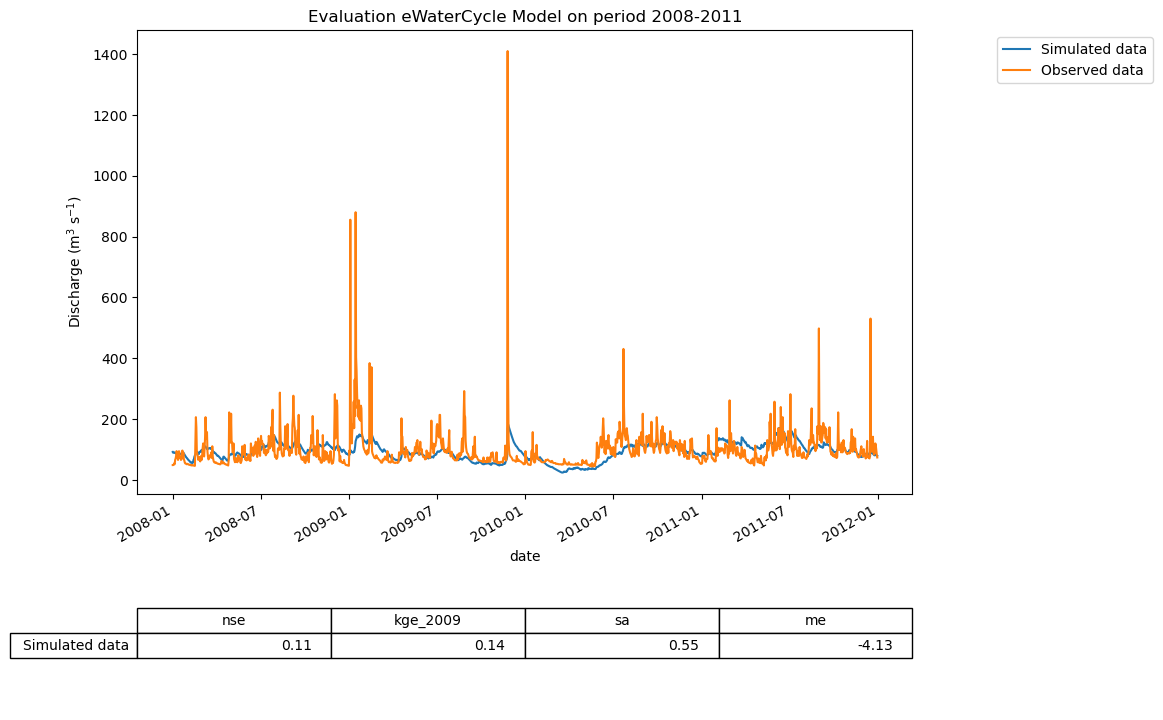

In [ ]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_20082011.png', title = 'Evaluation eWaterCycle Model on period 2008-2011')

### 2016-2019

In [ ]:
# Q observed 
obs = pd.read_excel('5202080_Q_Day.Cmd.txt', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['2016-01-01':'2019-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [ ]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
2016-01-01,54.588571,59.87
2016-01-02,53.113321,59.87
2016-01-03,52.105342,59.87
2016-01-04,50.890156,58.59
2016-01-05,49.914926,59.87
...,...,...
2019-12-27,57.487585,50.71
2019-12-28,56.464995,47.77
2019-12-29,54.973017,45.11


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 2016-2019'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

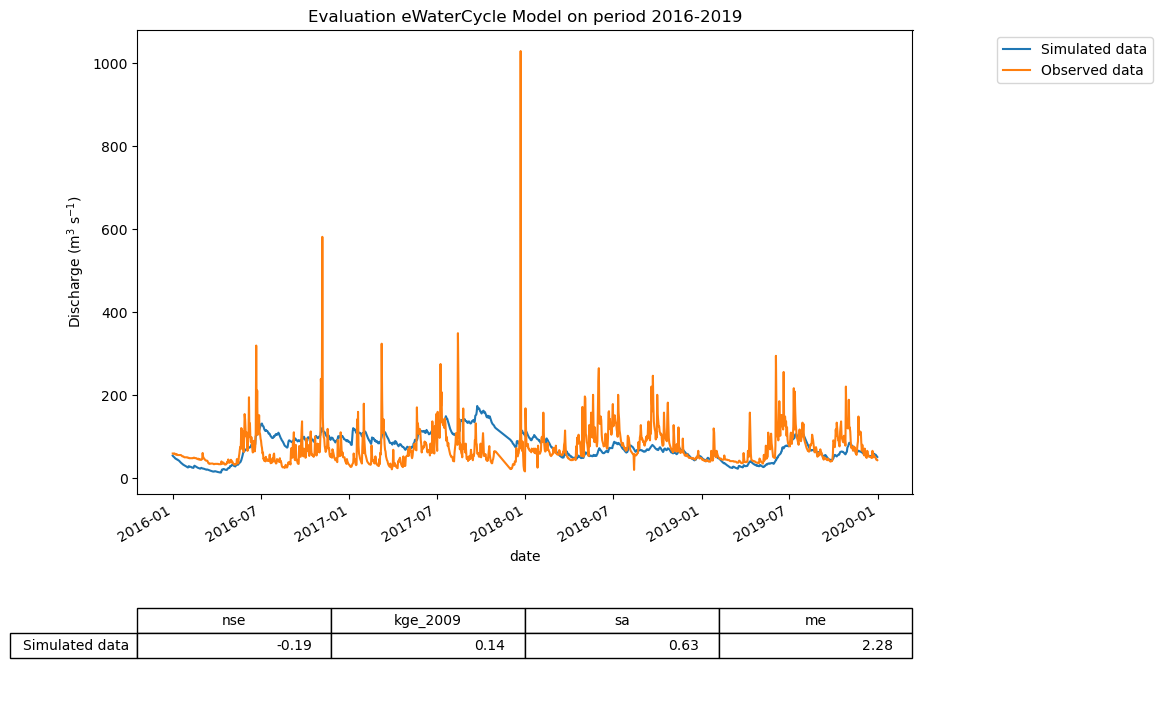

In [ ]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_20162019.png', title = 'Evaluation eWaterCycle Model on period 2016-2019')

### Entire timeseries

In [ ]:
# Q observed 
obs = pd.read_excel('5202080_Q_Day.Cmd.txt', index_col=[0])

obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

In [ ]:
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
1991-01-16,3.760654,44.30
1991-01-17,3.848015,40.00
1991-01-18,3.808072,40.00
1991-01-19,3.870473,40.00
1991-01-20,4.715331,40.00
...,...,...
2019-12-27,57.487585,50.71
2019-12-28,56.464995,47.77
2019-12-29,54.973017,45.11


(<Figure size 1500x1500 with 2 Axes>,
 (<Axes: title={'center': 'Evaluation eWaterCycle Model on period 1991-2019'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

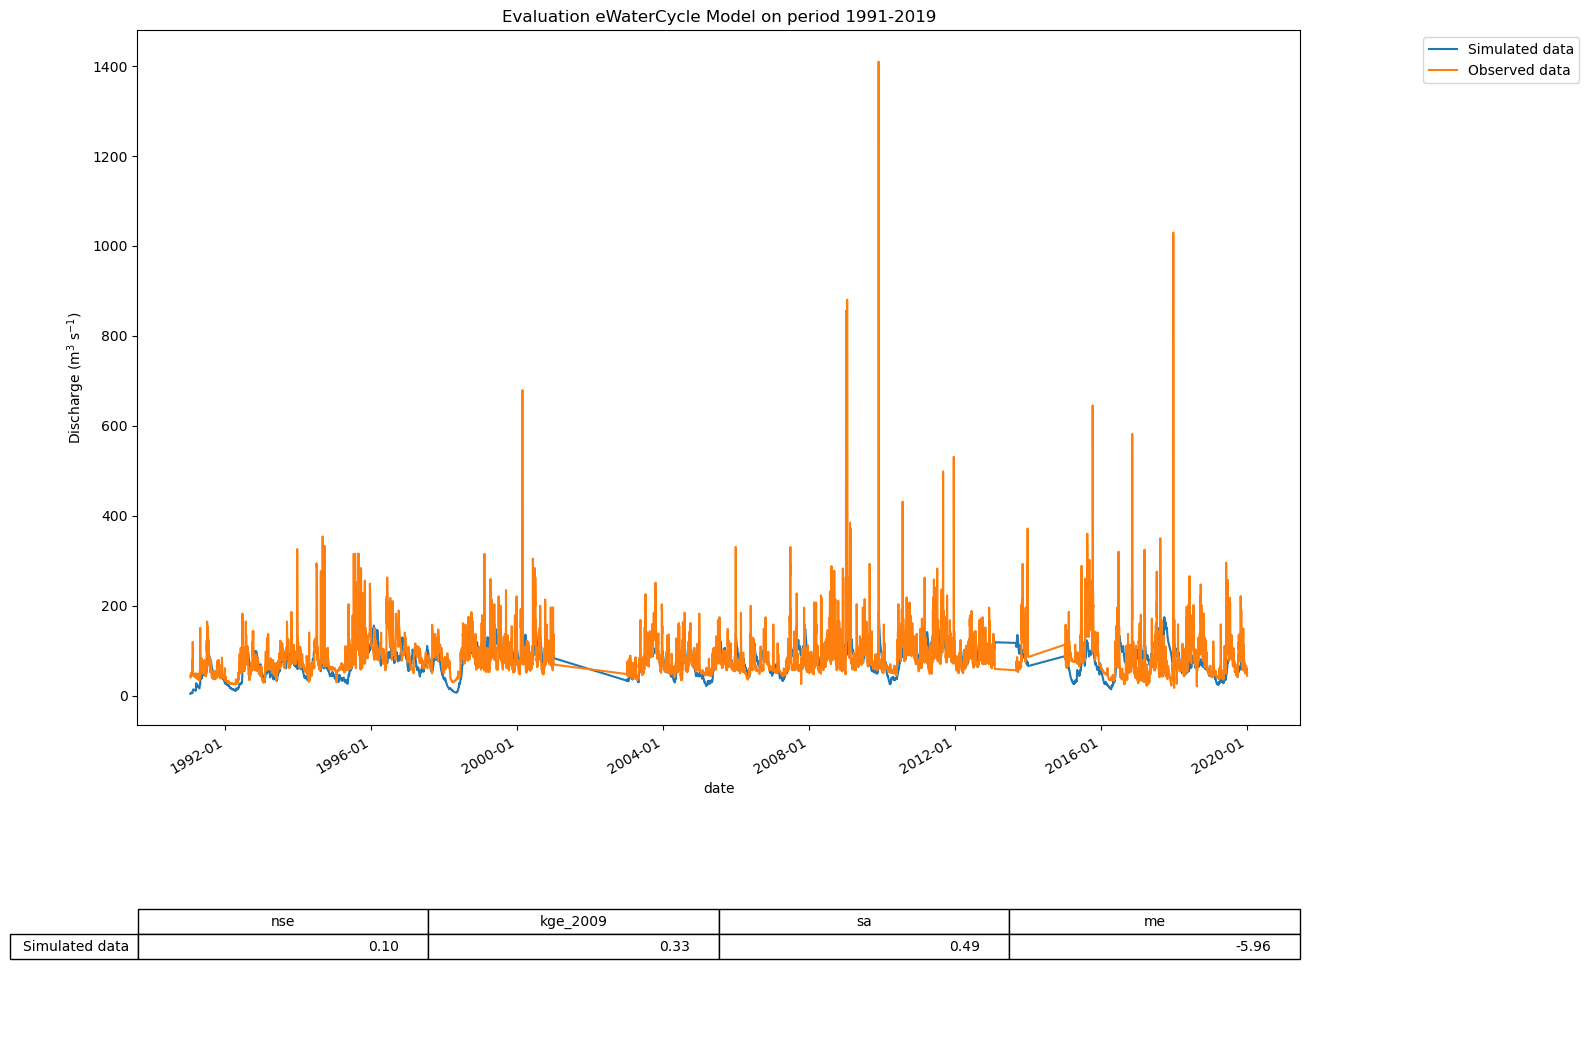

In [ ]:
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = './Evaluation Calibration/experiment_hydrograph_eval_19952019.png', title = 'Evaluation eWaterCycle Model on period 1991-2019', figsize=(15, 15))

## Note on files

Each model now has its own directory in the configFiles directory. If everything goes well, these are deleted with the ```finalize()``` command above. If however due to an error, they persist, you may not be able to create a new ensemble. In that case, uncomment the line in the cell below and run that. But be careful! this will remove all the files in the configFiles directory.

In [ ]:
# rm -r configFiles/*